<a href="https://colab.research.google.com/github/hassan-jamshaid10/FaceDetection-PersonlaityCheck-using-Salesforce-blip-image-captioning-base-Model/blob/main/FaceDetection%26PersonalityDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Face Detected


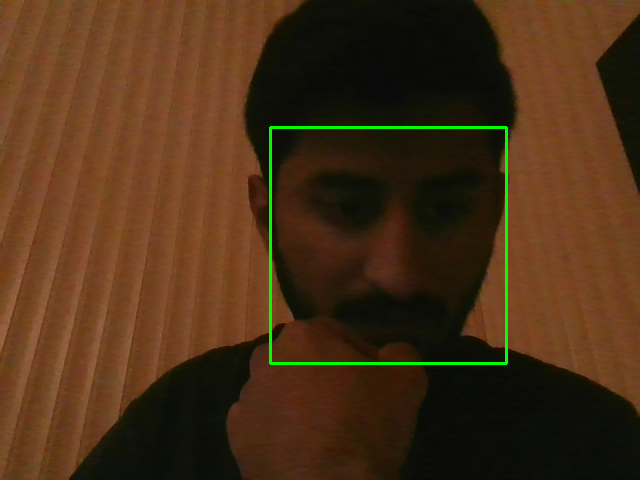

In [2]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import numpy as np


def take_photo():
    js = """
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        document.body.appendChild(video);
        video.srcObject = stream;
        await new Promise((resolve) => (video.onloadedmetadata = resolve));
        video.play();
        await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/png');
    }
    takePhoto();
    """
    return eval_js(js)

def detect_faces():
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)


    image_data = take_photo()
    if not image_data:
        print("No image captured.")
        return


    image_bytes = base64.b64decode(image_data.split(',')[1])
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)


    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_detection.process(image_rgb)

    if results.detections:
        print("Face Detected")
        for i, detection in enumerate(results.detections[:4]):
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        print("No Face Detected")

    cv2_imshow(image)


detect_faces()


In [15]:
# !pip uninstall numpy
# !pip install --no-cache-dir numpy==1.23.5
# !pip install --no-cache-dir mediapipe


# !pip uninstall numpy

# !pip install --upgrade numpy==1.26.0

# !pip install --no-cache-dir mediapipe
# !pip uninstall mediapipe -y
# !pip install --no-cache-dir mediapipe
# !pip cache purge
# !pip install --no-cache-dir mediapipe

!pip uninstall mediapipe -y
!pip install mediapipe==0.10.21




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 43.5 MB/s eta 0:00:00


In [16]:
# !pip install --upgrade protobuf grpcio grpcio-status opencv-python mediapipe

!pip install opencv-python==4.6.0.66 opencv-contrib-python==4.6.0.66


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 10.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.11.0.86
    Uninstalling opencv-contrib-python-4.11.0.86:
      Successfully uninstalled opencv-contrib-python-4.11.0.86


In [10]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
import base64
import numpy as np
from transformers import AutoModelForCausalLM
from peft import PeftModel
import torch
from PIL import Image
from io import BytesIO
from huggingface_hub import login

# Login to Hugging Face with your API token
login()

# JavaScript to capture webcam image in Colab
def take_photo():
    js = """
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        document.body.appendChild(video);
        video.srcObject = stream;
        await new Promise((resolve) => (video.onloadedmetadata = resolve));
        video.play();
        await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/png');
    }
    takePhoto();
    """
    return eval_js(js)

# Load the personality detection model
base_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B")
model = PeftModel.from_pretrained(base_model, "JerMa88/llama-3.2-1B-personality-detection-O")

# Move model to the correct device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to detect faces and analyze traits/personality
def detect_faces_and_analyze_traits():
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

    # Capture an image from the webcam
    image_data = take_photo()
    if not image_data:
        print("No image captured.")
        return

    # Decode the base64 image
    image_bytes = base64.b64decode(image_data.split(',')[1])
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

    # Convert to RGB for Mediapipe
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_detection.process(image_rgb)

    if results.detections:
        print("Face Detected")
        for i, detection in enumerate(results.detections[:4]):  # Limit to first 4 faces
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

            # Crop the face from the image
            face_crop = image[y:y+h, x:x+w]

            # Convert to PIL Image for Hugging Face
            pil_image = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
            buffered = BytesIO()
            pil_image.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')

            # Analyze personality traits
            result = analyze_personality_from_face(img_str)
            print("Personality Traits:", result)

            # Draw rectangle around the detected face
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        print("No Face Detected")

    cv2_imshow(image)

# Function to call Hugging Face model for personality analysis
def analyze_personality_from_face(img_str):
    # Convert the image string to text prompt for the model
    prompt = f"Analyze the personality and traits of this person based on their face: {img_str}"

    # Tokenize the prompt
    inputs = model.tokenizer(prompt, return_tensors="pt").to(device)

    # Get model output
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=100)

    # Decode and return the result
    result = outputs[0]
    decoded_result = model.tokenizer.decode(result, skip_special_tokens=True)

    return decoded_result

# Run the face detection and personality analysis
detect_faces_and_analyze_traits()


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/27.3M [00:00<?, ?B/s]

Face Detected


AttributeError: 'LlamaForCausalLM' object has no attribute 'tokenizer'

In [ ]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
import base64
import numpy as np
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from huggingface_hub import login
from PIL import Image
from io import BytesIO

# Login to Hugging Face with your API token
login('HF_token')

# Load the Vision-Language model (Aya Vision 8B)
processor = AutoProcessor.from_pretrained("CohereForAI/aya-vision-8b")
model = AutoModelForImageTextToText.from_pretrained("CohereForAI/aya-vision-8b")

# Move model to the correct device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# JavaScript to capture webcam image in Colab
def take_photo():
    js = """
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        document.body.appendChild(video);
        video.srcObject = stream;
        await new Promise((resolve) => (video.onloadedmetadata = resolve));
        video.play();
        await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/png');
    }
    takePhoto();
    """
    return eval_js(js)

# Function to detect faces and analyze traits/personality
def detect_faces_and_analyze_traits():
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

    # Capture an image from the webcam
    image_data = take_photo()
    if not image_data:
        print("No image captured.")
        return

    # Decode the base64 image
    image_bytes = base64.b64decode(image_data.split(',')[1])
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

    # Convert to RGB for Mediapipe
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_detection.process(image_rgb)

    if results.detections:
        print("Face Detected")
        for i, detection in enumerate(results.detections[:4]):  # Limit to first 4 faces
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

            # Crop the face from the image
            face_crop = image[y:y+h, x:x+w]

            # Convert to PIL Image for Hugging Face model
            pil_image = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))

            # Analyze personality traits
            result = analyze_personality_from_face(pil_image)
            print("Personality Traits:", result)

            # Draw rectangle around the detected face
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        print("No Face Detected")

    cv2_imshow(image)

# Function to analyze personality using Aya Vision model
def analyze_personality_from_face(pil_image):
    # Prepare input for the model
    inputs = processor(images=pil_image, text="Analyze the personality of this person based on their face.", return_tensors="pt").to(device)

    # Get model output
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=100)

    # Decode and return the result
    result = processor.tokenizer.decode(outputs[0], skip_special_tokens=True)

    return result

# Run the face detection and personality analysis
detect_faces_and_analyze_traits()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some kwargs in processor config are unused and will not have any effect: vision_feature_select_strategy. 


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Face Detected
Personality Traits: a man with a beard


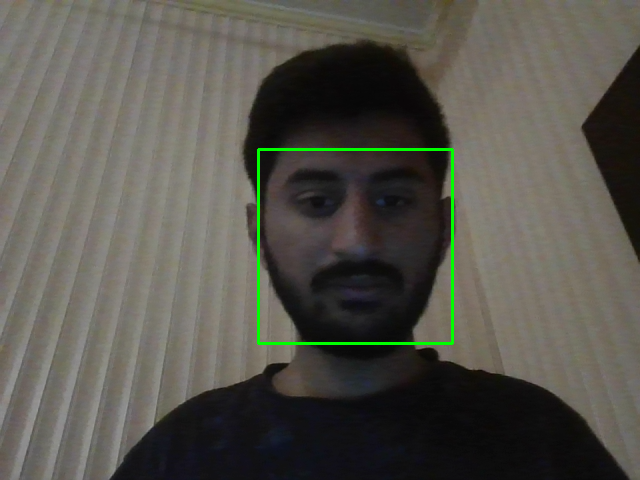

In [15]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
import base64
import numpy as np
import torch
from PIL import Image
from io import BytesIO
from transformers import AutoProcessor, AutoModelForVision2Seq


processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = AutoModelForVision2Seq.from_pretrained("Salesforce/blip-image-captioning-base")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def take_photo():
    js = """
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        document.body.appendChild(video);
        video.srcObject = stream;
        await new Promise((resolve) => (video.onloadedmetadata = resolve));
        video.play();
        await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/png');
    }
    takePhoto();
    """
    return eval_js(js)


def detect_faces_and_analyze_traits():
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)


    image_data = take_photo()
    if not image_data:
        print("No image captured.")
        return


    image_bytes = base64.b64decode(image_data.split(',')[1])
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)


    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_detection.process(image_rgb)

    if results.detections:
        print("Face Detected")
        for i, detection in enumerate(results.detections[:4]):
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)
            face_crop = image[y:y+h, x:x+w]
            pil_image = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
            result = analyze_personality_from_face(pil_image)
            print("Personality Traits:", result)
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        print("No Face Detected")

    cv2_imshow(image)

def analyze_personality_from_face(image):

    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=100)
    decoded_result = processor.tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded_result


detect_faces_and_analyze_traits()


Face Detected

🔹 **Personality Traits:** a man with a beard
🔹 **Physical Characteristics:** a man with a beard
🔹 **Mood Detected:** a man with a beard
🔹 **Estimated Age:** a man with a beard


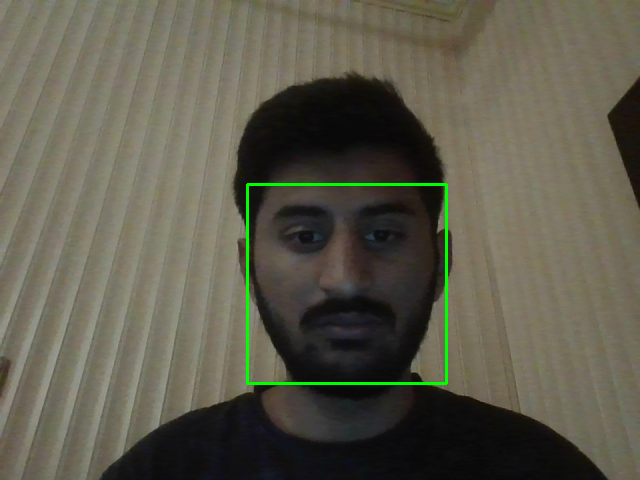

In [10]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
import base64
import numpy as np
import torch
from PIL import Image
from io import BytesIO
from transformers import AutoProcessor, AutoModelForVision2Seq

# Load BLIP model for image-text processing
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = AutoModelForVision2Seq.from_pretrained("Salesforce/blip-image-captioning-base")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# JavaScript to capture webcam image in Colab
def take_photo():
    js = """
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });
        document.body.appendChild(video);
        video.srcObject = stream;
        await new Promise((resolve) => (video.onloadedmetadata = resolve));
        video.play();
        await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        document.body.removeChild(video);
        return canvas.toDataURL('image/png');
    }
    takePhoto();
    """
    return eval_js(js)

# Function to detect faces and analyze personality, characteristics, mood, and age
def detect_faces_and_analyze_traits():
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

    # Capture an image from the webcam
    image_data = take_photo()
    if not image_data:
        print("No image captured.")
        return

    # Decode the base64 image
    image_bytes = base64.b64decode(image_data.split(',')[1])
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

    # Convert to RGB for Mediapipe
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_detection.process(image_rgb)

    if results.detections:
        print("Face Detected")
        for i, detection in enumerate(results.detections[:4]):  # Limit to first 4 faces
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = image.shape
            x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

            # Crop the face from the image
            face_crop = image[y:y+h, x:x+w]

            # Convert to PIL Image for the BLIP model
            pil_image = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))

            # Analyze personality, characteristics, mood, and age
            personality, characteristics, mood, age = analyze_face(pil_image)
            print("\n🔹 **Personality Traits:**", personality)
            print("🔹 **Physical Characteristics:**", characteristics)
            print("🔹 **Mood Detected:**", mood)
            print("🔹 **Estimated Age:**", age)

            # Draw rectangle around the detected face
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    else:
        print("No Face Detected")

    cv2_imshow(image)

# Function to analyze personality, characteristics, mood, and age using BLIP model
def analyze_face(image):
    # Preprocess image
    inputs = processor(images=image, return_tensors="pt").to(device)

    # Generate personality traits
    with torch.no_grad():
        personality_outputs = model.generate(**inputs, max_length=100)

    # Generate physical characteristics
    with torch.no_grad():
        characteristics_outputs = model.generate(**inputs, max_length=100)

    # Generate mood detection
    with torch.no_grad():
        mood_outputs = model.generate(**inputs, max_length=100)

    # Generate age estimation
    with torch.no_grad():
        age_outputs = model.generate(**inputs, max_length=100)

    # Decode results
    personality_text = processor.tokenizer.decode(personality_outputs[0], skip_special_tokens=True)
    characteristics_text = processor.tokenizer.decode(characteristics_outputs[0], skip_special_tokens=True)
    mood_text = processor.tokenizer.decode(mood_outputs[0], skip_special_tokens=True)
    age_text = processor.tokenizer.decode(age_outputs[0], skip_special_tokens=True)

    return personality_text, characteristics_text, mood_text, age_text

# Run the face detection and personality analysis
detect_faces_and_analyze_traits()


In [14]:
# import cv2
# import mediapipe as mp
# from google.colab.patches import cv2_imshow
# from google.colab.output import eval_js
# import base64
# import numpy as np
# import torch
# from PIL import Image
# from io import BytesIO
# from transformers import AutoTokenizer, AutoModelForCausalLM
# from deepface import DeepFace

# # Load a better personality analysis model (LLaMA-based)
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf")
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf")

# # Move model to GPU if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # JavaScript to capture webcam image in Colab
# def take_photo():
#     js = """
#     async function takePhoto() {
#         const video = document.createElement('video');
#         const stream = await navigator.mediaDevices.getUserMedia({ video: true });
#         document.body.appendChild(video);
#         video.srcObject = stream;
#         await new Promise((resolve) => (video.onloadedmetadata = resolve));
#         video.play();
#         await new Promise((resolve) => setTimeout(resolve, 1000)); // Give time for camera to adjust
#         const canvas = document.createElement('canvas');
#         canvas.width = video.videoWidth;
#         canvas.height = video.videoHeight;
#         canvas.getContext('2d').drawImage(video, 0, 0);
#         stream.getTracks().forEach(track => track.stop());
#         document.body.removeChild(video);
#         return canvas.toDataURL('image/png');
#     }
#     takePhoto();
#     """
#     return eval_js(js)

# # Function to detect faces and analyze personality, characteristics, mood, and age
# def detect_faces_and_analyze_traits():
#     mp_face_detection = mp.solutions.face_detection
#     face_detection = mp_face_detection.FaceDetection(min_detection_confidence=0.5)

#     # Capture an image from the webcam
#     image_data = take_photo()
#     if not image_data:
#         print("No image captured.")
#         return

#     # Decode the base64 image
#     image_bytes = base64.b64decode(image_data.split(',')[1])
#     image_np = np.frombuffer(image_bytes, dtype=np.uint8)
#     image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

#     # Convert to RGB for Mediapipe
#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     results = face_detection.process(image_rgb)

#     if results.detections:
#         print("Face Detected")
#         for i, detection in enumerate(results.detections[:4]):  # Limit to first 4 faces
#             bboxC = detection.location_data.relative_bounding_box
#             h, w, _ = image.shape
#             x, y, w, h = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

#             # Crop the face from the image
#             face_crop = image[y:y+h, x:x+w]

#             # Convert to PIL Image for DeepFace and LLaMA
#             pil_image = Image.fromarray(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))

#             # Analyze personality, characteristics, mood, and age
#             personality, characteristics, mood, age = analyze_face(face_crop)
#             print("\n🔹 **Personality Traits:**", personality)
#             print("🔹 **Physical Characteristics:**", characteristics)
#             print("🔹 **Mood Detected:**", mood)
#             print("🔹 **Estimated Age:**", age)

#             # Draw rectangle around the detected face
#             cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
#     else:
#         print("No Face Detected")

#     cv2_imshow(image)

# # Function to analyze personality, characteristics, mood, and age
# def analyze_face(image):
#     # DeepFace analysis (for age, gender, emotion)
#     analysis = DeepFace.analyze(image, actions=['age', 'gender', 'emotion'], enforce_detection=False)[0]

#     # Extract age, gender, and mood
#     age_text = f"{analysis['age']} years old"
#     characteristics_text = f"Gender: {analysis['gender']}"

#     # Get top mood prediction
#     mood_text = max(analysis['emotion'], key=analysis['emotion'].get)

#     # Generate personality traits using LLaMA
#     prompt = f"Analyze the personality of a person with the following features:\nAge: {age_text}\nGender: {characteristics_text}\nMood: {mood_text}\nProvide a short description of their personality."

#     inputs = tokenizer(prompt, return_tensors="pt").to(device)
#     with torch.no_grad():
#         outputs = model.generate(**inputs, max_length=100)
#     personality_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

#     return personality_text, characteristics_text, mood_text, age_text

# # Run the face detection and personality analysis
# detect_faces_and_analyze_traits()


In [12]:
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=b6ff5474806a8d80da58a5c3e3c78e04c4518c16f60c37d59a67e8f465256e2a
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire
